In [17]:
import os

os.environ.setdefault("KERAS_BACKEND", "torch")

from keras.models import Sequential
from keras.layers import Conv2D, Dense, Dropout, Flatten, MaxPooling2D
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

In [18]:
from keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

/home/ivan/Projects/nuralnetworks/.venv/lib/python3.14/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [19]:
print(type(x_train))
print(type(y_train))
print(type(x_test))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [20]:
print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [21]:
index = 0
x_train[index]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

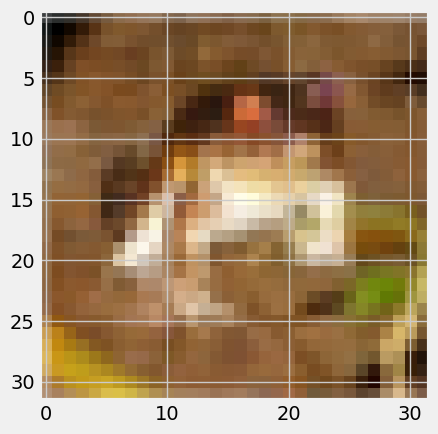

In [22]:
img = plt.imshow(x_train[index])
plt.show()

In [23]:
print('The image label is: ', y_train[index])

classification = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print('The image class is: ', classification[y_train[index][0]])

The image label is:  [6]
The image class is:  frog


In [24]:
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

print(y_train_one_hot)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]


In [25]:
x_train = x_train / 255
x_test = x_test / 255

In [26]:
from sklearn.model_selection import train_test_split
from keras.src.legacy.preprocessing.image import ImageDataGenerator

idx = np.arange(len(x_train))
idx_train, idx_val = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y_train.ravel()
)
x_tr = x_train[idx_train]
x_val = x_train[idx_val]
y_tr = y_train_one_hot[idx_train]
y_val = y_train_one_hot[idx_val]

datagen = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
)
train_gen = datagen.flow(x_tr, y_tr, batch_size=256, seed=42)


In [27]:
model = Sequential()
model.add(Conv2D(32, (5, 5), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (5, 5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(1000, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(500, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(250, activation='relu'))
model.add(Dense(10, activation='softmax'))


/home/ivan/Projects/nuralnetworks/.venv/lib/python3.14/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_delta=1e-4,
        min_lr=1e-6,
        verbose=1,
    ),
]

steps = len(train_gen)
hist = model.fit(
    train_gen,
    steps_per_epoch=steps,
    epochs=80,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
)


Epoch 1/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 208ms/step - accuracy: 0.3096 - loss: 1.8334 - val_accuracy: 0.4522 - val_loss: 1.4955 - learning_rate: 0.0010
Epoch 2/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 240ms/step - accuracy: 0.4572 - loss: 1.4815 - val_accuracy: 0.5356 - val_loss: 1.2682 - learning_rate: 0.0010
Epoch 3/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 231ms/step - accuracy: 0.5130 - loss: 1.3516 - val_accuracy: 0.5734 - val_loss: 1.2000 - learning_rate: 0.0010
Epoch 4/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 264ms/step - accuracy: 0.5511 - loss: 1.2541 - val_accuracy: 0.5511 - val_loss: 1.2764 - learning_rate: 0.0010
Epoch 5/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 276ms/step - accuracy: 0.5711 - loss: 1.2024 - val_accuracy: 0.6180 - val_loss: 1.1037 - learning_rate: 0.0010
Epoch 6/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 269ms/step - accuracy: 0.5907 - loss: 1.1557 - val_accuracy: 0.6232 - val_loss: 1.0800 - learning_rate: 0.0010
Epoch 7/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 264ms/step - accuracy: 0.6

In [29]:
model.evaluate(x_test, y_test_one_hot)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7936 - loss: 0.5899


0.7936000227928162

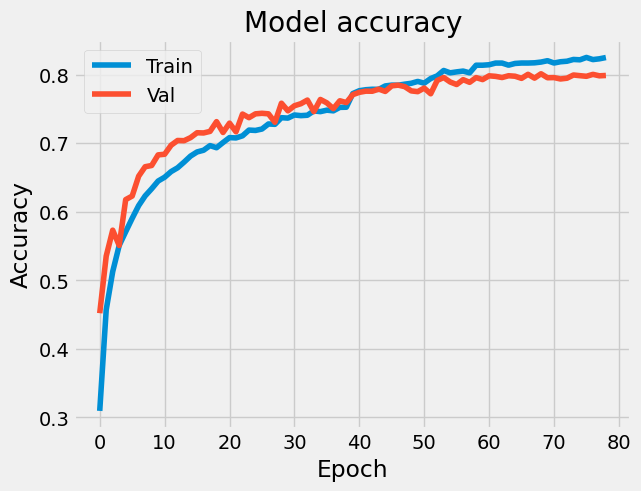

In [30]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

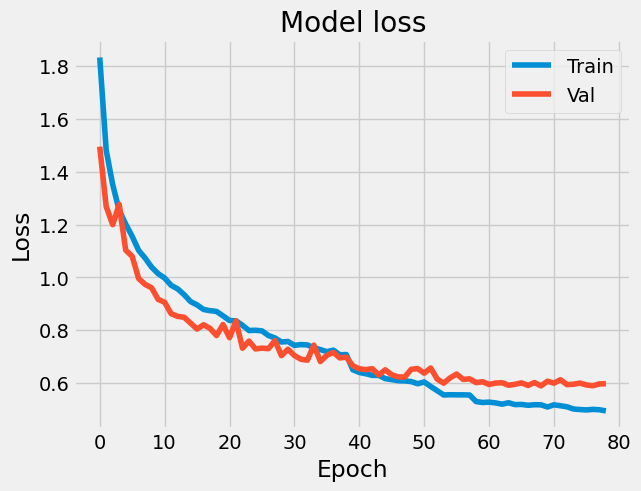

In [31]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

In [32]:
from pathlib import Path
import numpy as np
from skimage.transform import resize

IMAGES_DIR = Path("images")
EXTS = {".png", ".jpg", ".jpeg", ".webp"}
IMAGE_PATHS = sorted(p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in EXTS)


def load_rgb(path):
    arr = np.asarray(plt.imread(path), dtype=np.float64)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    elif arr.ndim == 3 and arr.shape[-1] == 4:
        arr = arr[..., :3]
    elif arr.ndim == 3 and arr.shape[-1] == 1:
        arr = np.repeat(arr, 3, axis=-1)
    return arr


if not IMAGE_PATHS:
    print("No images found in", IMAGES_DIR.resolve())
else:
    x_batch = np.stack(
        [resize(load_rgb(path), (32, 32, 3), anti_aliasing=True) for path in IMAGE_PATHS]
    )
    probs = model.predict(x_batch, verbose=0)

    for path, pred in zip(IMAGE_PATHS, probs):
        order = np.argsort(-pred)[:5]
        print(path.name)
        for rank, k in enumerate(order, 1):
            print(f"  {rank}. {classification[k]}: {100 * pred[k]:.2f}%")
        print()


airplane.png
  1. airplane: 95.66%
  2. bird: 4.31%
  3. ship: 0.01%
  4. frog: 0.01%
  5. deer: 0.00%

automobile.png
  1. automobile: 100.00%
  2. truck: 0.00%
  3. ship: 0.00%
  4. airplane: 0.00%
  5. frog: 0.00%

bird.png
  1. bird: 99.08%
  2. airplane: 0.90%
  3. cat: 0.01%
  4. frog: 0.00%
  5. dog: 0.00%

cat.png
  1. cat: 99.00%
  2. dog: 0.94%
  3. deer: 0.02%
  4. horse: 0.01%
  5. frog: 0.01%

deer.png
  1. deer: 89.93%
  2. frog: 7.69%
  3. cat: 1.24%
  4. dog: 0.53%
  5. bird: 0.42%

dog.png
  1. dog: 99.98%
  2. bird: 0.02%
  3. cat: 0.00%
  4. horse: 0.00%
  5. frog: 0.00%

frog.png
  1. frog: 99.88%
  2. airplane: 0.07%
  3. bird: 0.04%
  4. cat: 0.01%
  5. truck: 0.00%

horse.png
  1. horse: 99.86%
  2. dog: 0.12%
  3. deer: 0.02%
  4. cat: 0.00%
  5. bird: 0.00%

ship.png
  1. ship: 99.34%
  2. airplane: 0.62%
  3. cat: 0.01%
  4. truck: 0.01%
  5. bird: 0.01%

truck.png
  1. truck: 99.97%
  2. automobile: 0.03%
  3. ship: 0.00%
  4. airplane: 0.00%
  5. dog: 0.00%
